In [1]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import anndata as ad
import statistics
import torch
import scvi
import cosg
import celltypist
import tempfile
import sklearn
import mudata as md
import muon as mu
md.set_options(pull_on_update=False)
import muon
import decoupler as dc
from datetime import datetime
from scib_metrics.benchmark import Benchmarker
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from multiprocessing import Pool
import uuid
print("Last run with scvi-tools version:", scvi.__version__)
scvi.settings.num_threads = 16
scvi.settings.seed = 0
sc._settings.n_jobs=16
sc.settings.verbosity = 4
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)

/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
Seed set to 0


Last run with scvi-tools version: 1.3.0


In [2]:
os.environ["R_HOME"] = "/home/liyanguo/anaconda3/envs/R/lib/R/"
import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 4
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

cffi mode is CFFI_MODE.ANY
R home found: /home/liyanguo/anaconda3/envs/R/lib/R/
R library path: WARNING: ignoring environment value of R_HOME

LD_LIBRARY_PATH: WARNING: ignoring environment value of R_HOME

Default options to initialize R: rpy2, --quiet, --no-save
R is already initialized. No need to initialize.
/tmp/ipykernel_1425798/2160647699.py:13: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [3]:
%%R
suppressPackageStartupMessages({
    library(Seurat)
    library(clusterProfiler)
    library(ggplot2)
    library(dplyr)
    library(anndata)
    library(SingleCellExperiment)
    library(reticulate)
    library(edgeR)
    library(MAST)
    library(limma)
})
use_python("/home/liyanguo/anaconda3/envs/R/bin/python")
sc <- import("scanpy")
celltypist <- import("celltypist")


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [4]:
sc.logging.print_header()

Package,Version
ipykernel,6.29.5
scipy,1.11.4
numpy,1.26.4
pandas,2.2.3
scanpy,1.11.2
seaborn,0.13.2
matplotlib,3.9.2
anndata,0.11.4
torch,2.4.1 (2.4.1+cu121)
scvi-tools,1.3.0


In [5]:
Classification='Classification_L2'
dataset='B_cells'
groupby='Classification_L4'

In [6]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [7]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count.h5ad")

In [8]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [9]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)

/tmp/ipykernel_1425798/1858493966.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels.csv",index_col=0)


In [10]:
indices = indices[['Classification_L4','Classification_L3','Classification_L2','Classification_L1',
                   #'leiden_cluster',
                  ]]

In [11]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [ ]:
if (adt.obs.index == indices.index).all():
    adt.obs = adt.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [13]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [14]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [15]:
adt.strings_to_categoricals()

# 1. Maker Genes by using FindAllMarkers roc and count

In [16]:
# downsample_adata for seurat
if adata.n_obs > 100000:
    cell_indices = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 100000,
                                                     by = groupby,random_state=0)
    adata_sampled = adata[cell_indices].copy()
else:
    adata_sampled = adata.copy()

In [17]:
adata_sampled.layers['count'] = adata_sampled.X.copy()
sc.pp.normalize_total(adata_sampled, target_sum=1e4)
sc.pp.log1p(adata_sampled)

normalizing counts per cell
    finished (0:00:01)


In [18]:
#for python
if len(adata.obs[groupby].unique())>1:
    adata_sampled.write(f"{obj_path}{dataset}_tmp.h5ad")
    os.system(f"Rscript /home/liyanguo/MyImmuCell/00_code_MyImmuCell/DEG_ROC.R {obj_path} {dataset} {groupby} &")

# 4. Maker Genes cosg

In [19]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:39)


In [20]:
sc.pp.log1p(adata)

In [21]:
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=100,n_genes_user=100,remove_lowly_expressed=True,expressed_pct=0.1,
          )

Normalizing layer: counts
Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|


In [22]:
xlsx = pd.ExcelWriter(f"{obj_path}cosg_genes_{dataset}_{groupby}.xlsx")
pd.DataFrame(adata.uns[f'cosg_{groupby}']['names']).to_excel(xlsx,sheet_name='names')
pd.DataFrame(adata.uns[f'cosg_{groupby}']['scores']).to_excel(xlsx,sheet_name='scores')
xlsx.close()

# 5. Maker Genes Pathway Enrich

In [23]:
FeatureMatrix = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])

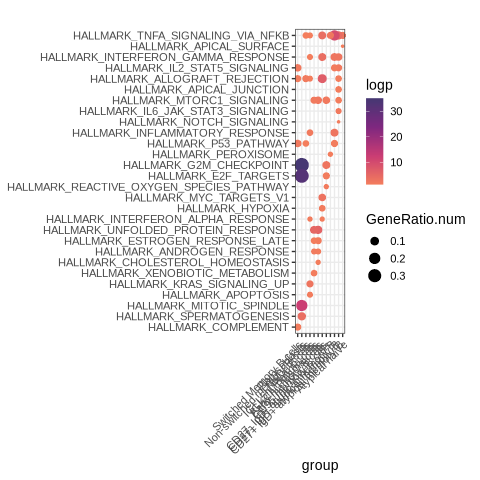

In [24]:
%%R -i FeatureMatrix,obj_path,groupby
source('GetEnrich.R')
GetEnrich(FeatureMatrix,plot_term_number = 10,R_data_path=obj_path,groupby=groupby,
          gmtfile="/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt")
#"/home/liyanguo/Marker/Immunity_PBMC.gmt"
#"/home/liyanguo/Marker/sepsis_PBMC.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c5.go.bp.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt"

# 6. Maker Genes GSEA

In [25]:
moncao = pd.read_excel("/home/liyanguo/Marker/Moncao_immune_cell_dataset.xlsx",sheet_name='FoldChange TPM')

In [26]:
moncao.columns = moncao.columns.str.replace('/', '_', regex=True)

In [27]:
del moncao['Ensembl ID']
del moncao['Entrez ID']

In [28]:
resource = pd.DataFrame(columns=['source', 'target',  'weight'])
for cell_type in moncao.columns[1:]:
    temp_df = moncao[['Gene name', cell_type]].copy()
    temp_df.columns = ['target', 'weight']
    temp_df['source'] = cell_type
    resource = pd.concat([resource, temp_df],ignore_index=True)

In [29]:
resource = resource.drop_duplicates(subset=['source', 'target'])

In [30]:
dc.mt.ulm(data=adata, net=resource)

Calculating cluster Atypical naïve
Calculating cluster CD27+ IgD+ atypical memory B
Calculating cluster CD27+ IgD- atypical memory B
Calculating cluster CD27- IgD- atypical memory B
Calculating cluster CD95 memory B cells
Calculating cluster Early memory B cells
Calculating cluster IGKChi Plasma cells
Calculating cluster IGLL5hi Plasma cells


In [31]:
score = dc.pp.get_obsm(adata, key='score_ulm')

computing PCA
    with n_comps=50


Calculating cluster Naïve B cells


    finished (0:00:18)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])
Storing dendrogram info using `.uns['dendrogram_Classification_L4']`


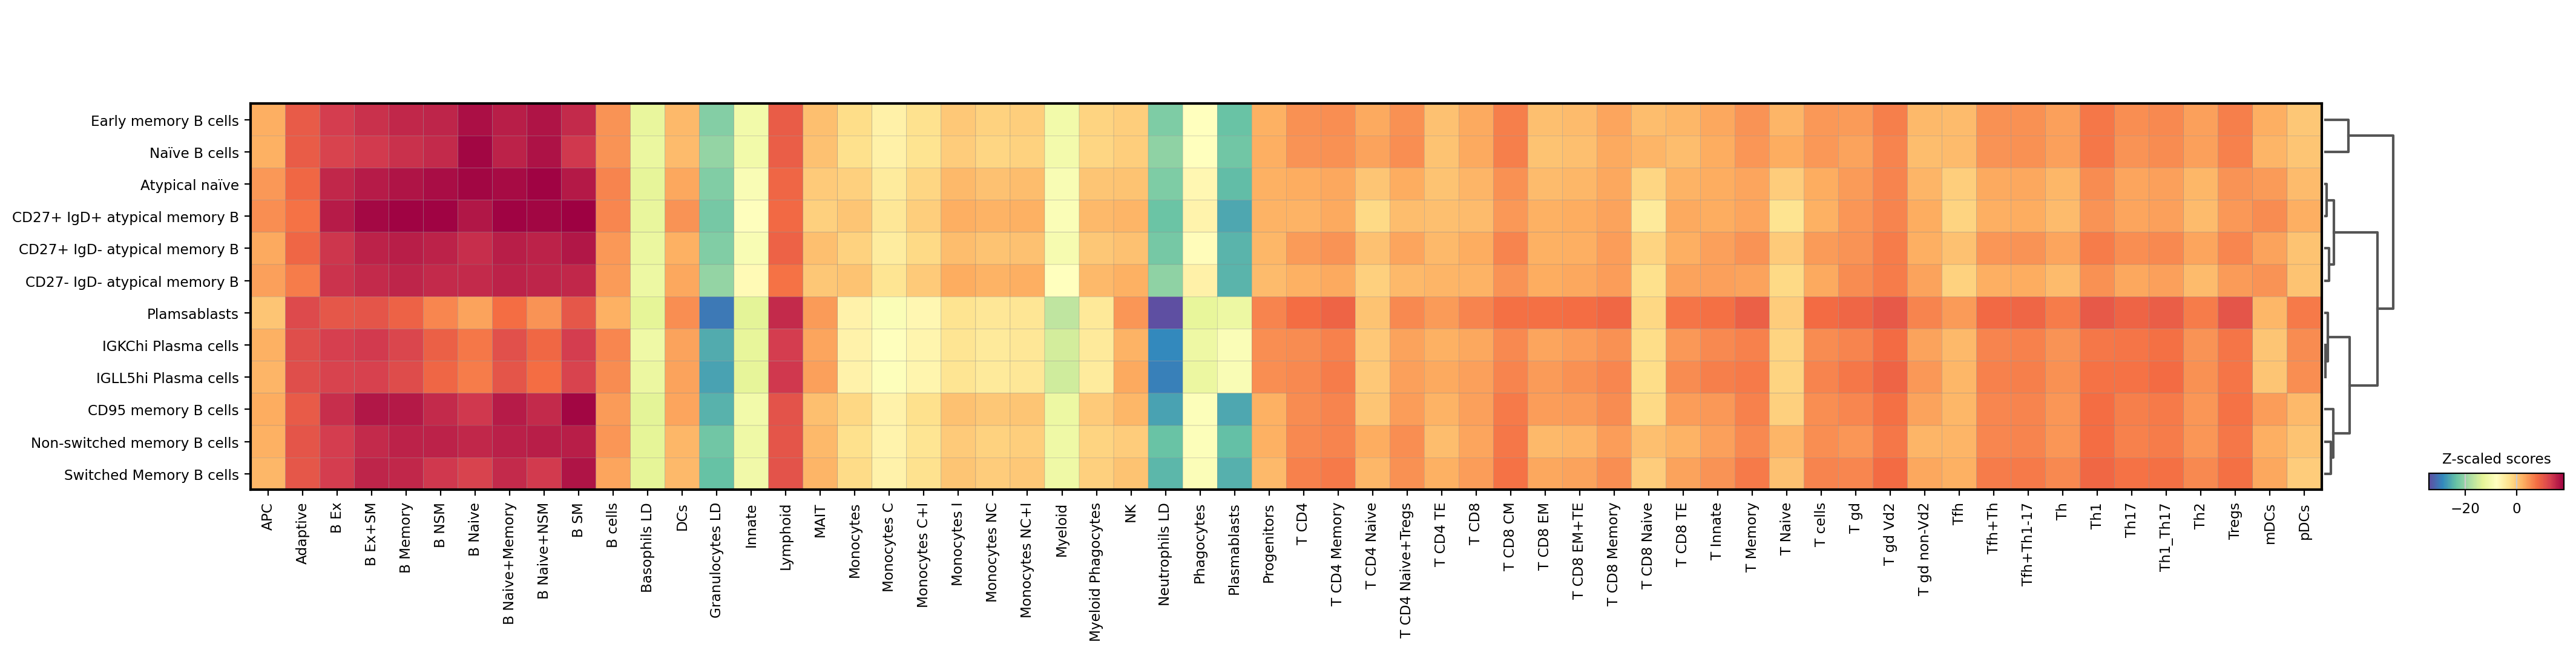

In [32]:
sc.pl.matrixplot(
    adata=score,
    var_names=score.var_names,
    groupby='Classification_L4',
    dendrogram=True,
    colorbar_title='Z-scaled scores',
    cmap='Spectral_r',
    save=f'{dataset}_{groupby}.png',
)

# 7. Process adt

In [33]:
adt.X.max()

2009.0

In [34]:
adt.layers["clr"] = mu.prot.pp.clr(adt,inplace= False).X.copy()

In [35]:
adt_dict={
    "CD45RA": ["CD45RA"],
    
    'B': ['IgD','IgM',"CD19",'CD27','CD137'],
    
    "ILC|NK|NKT|γδ T|": ["CD56","CD161",'CD16',],
    
    "T": ["CD3","CD4","CD8",'CD27','CD28','CD134','CD272'],
    "Naive/Memory T": ["CD45RA","CD127","CD62L",'CD197',],
    "Treg":['CD25','CD137','CD357',],
    "Th1|ILC":["CD183",'CD186','CD366'],
    "Th17|ILC":['CD161','CD196',],
    "Tfh|ILC|Effector":['CD185','CD278','CD279',],

    'DC':['CD11c','HLA-DR',"CD183",'CD197'],

    'Monocytes':['CD14','CD16'],
}

In [36]:
sc.pl.dotplot(
adt,
groupby=groupby,
var_names=adt_dict,
save=f"{dataset}_{groupby}_scADT_TOTALVI_clr",layer='clr',
expression_cutoff=1,
dot_min=0.1,
show=False,
)

{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

Calculating cluster Non-switched memory B cells
Calculating cluster Plamsablasts
Calculating cluster Switched Memory B cells


[1] TRUE


In [ ]:
import session_info
session_info.show()

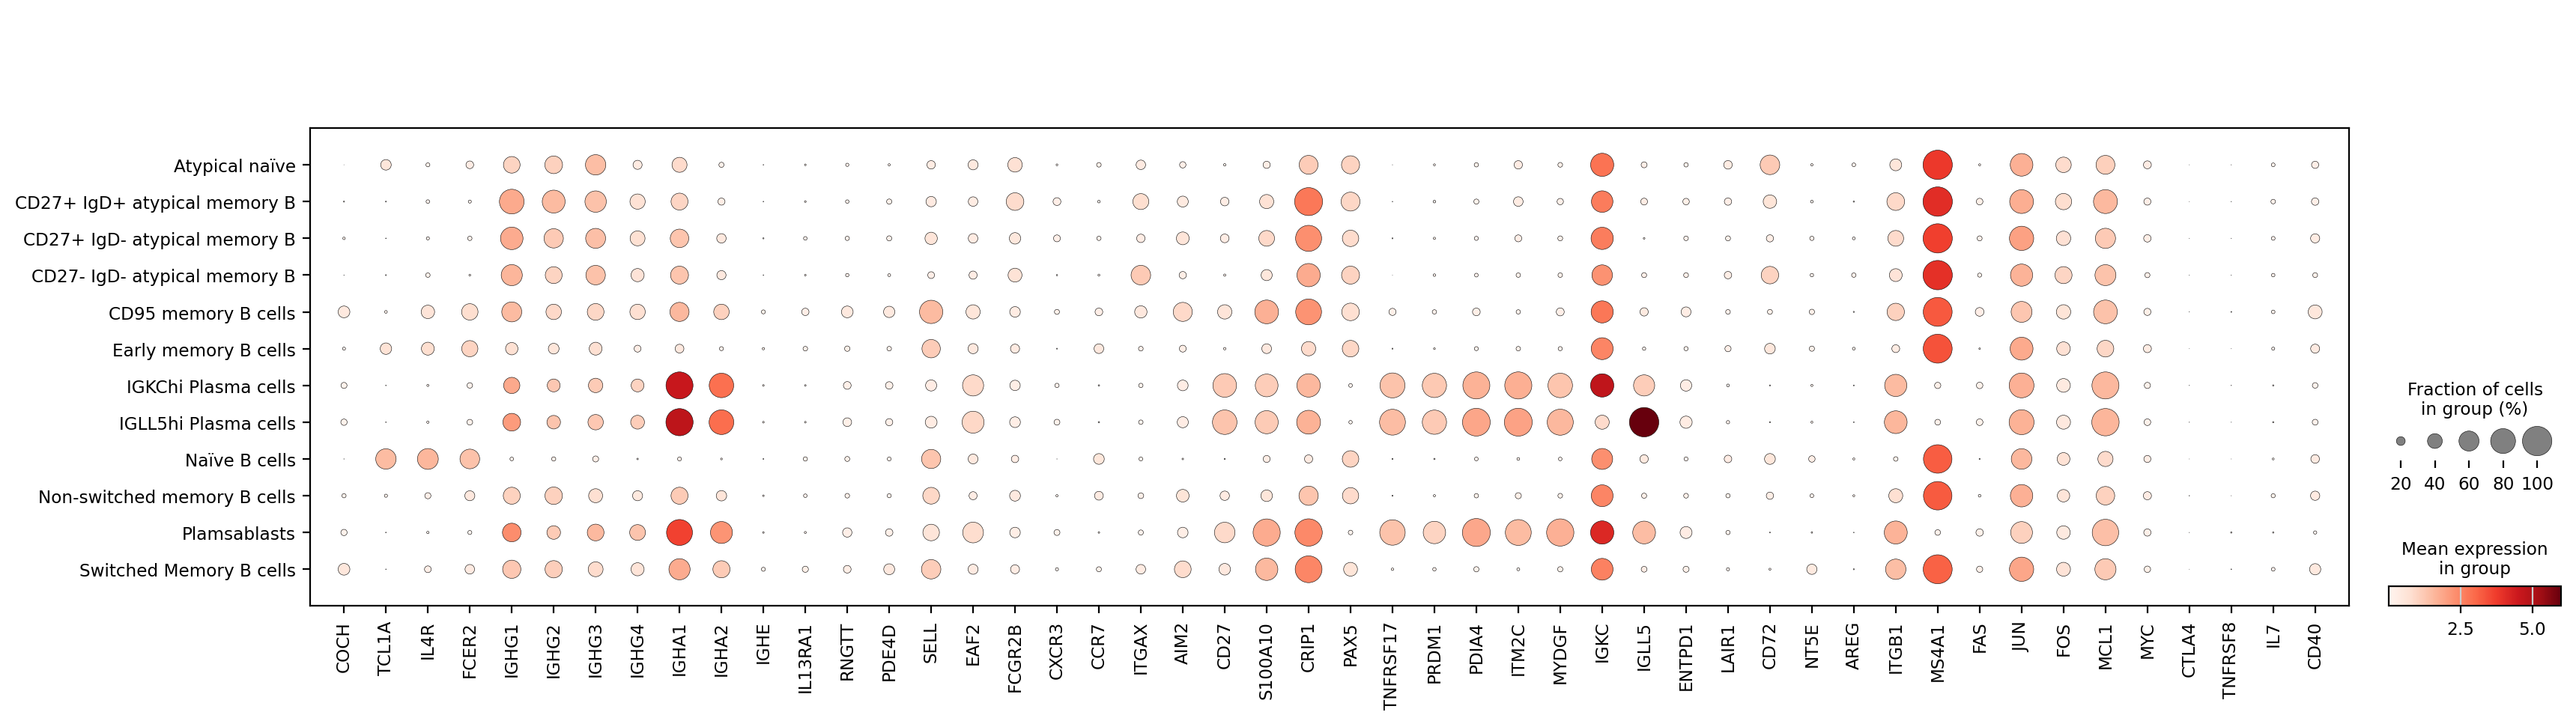

In [50]:
sc.pl.dotplot(adata, ['COCH','TCL1A','IL4R','FCER2','IGHG1','IGHG2','IGHG3','IGHG4','IGHA1','IGHA2',
                      'IGHE','IL13RA1','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX',
                      'AIM2','CD27','S100A10','CRIP1','PAX5','TNFRSF17','PRDM1', 'PDIA4','ITM2C','MYDGF','IGKC','IGLL5',

                      'ENTPD1','LAIR1','CD72',
                     'NT5E','AREG','ITGB1','MS4A1','FAS','JUN','FOS','MCL1','MYC','CTLA4','TNFRSF8','IL7','CD40'],
              #standard_scale='group',
              groupby=groupby,
              save=f"{dataset}_{groupby}_gene")

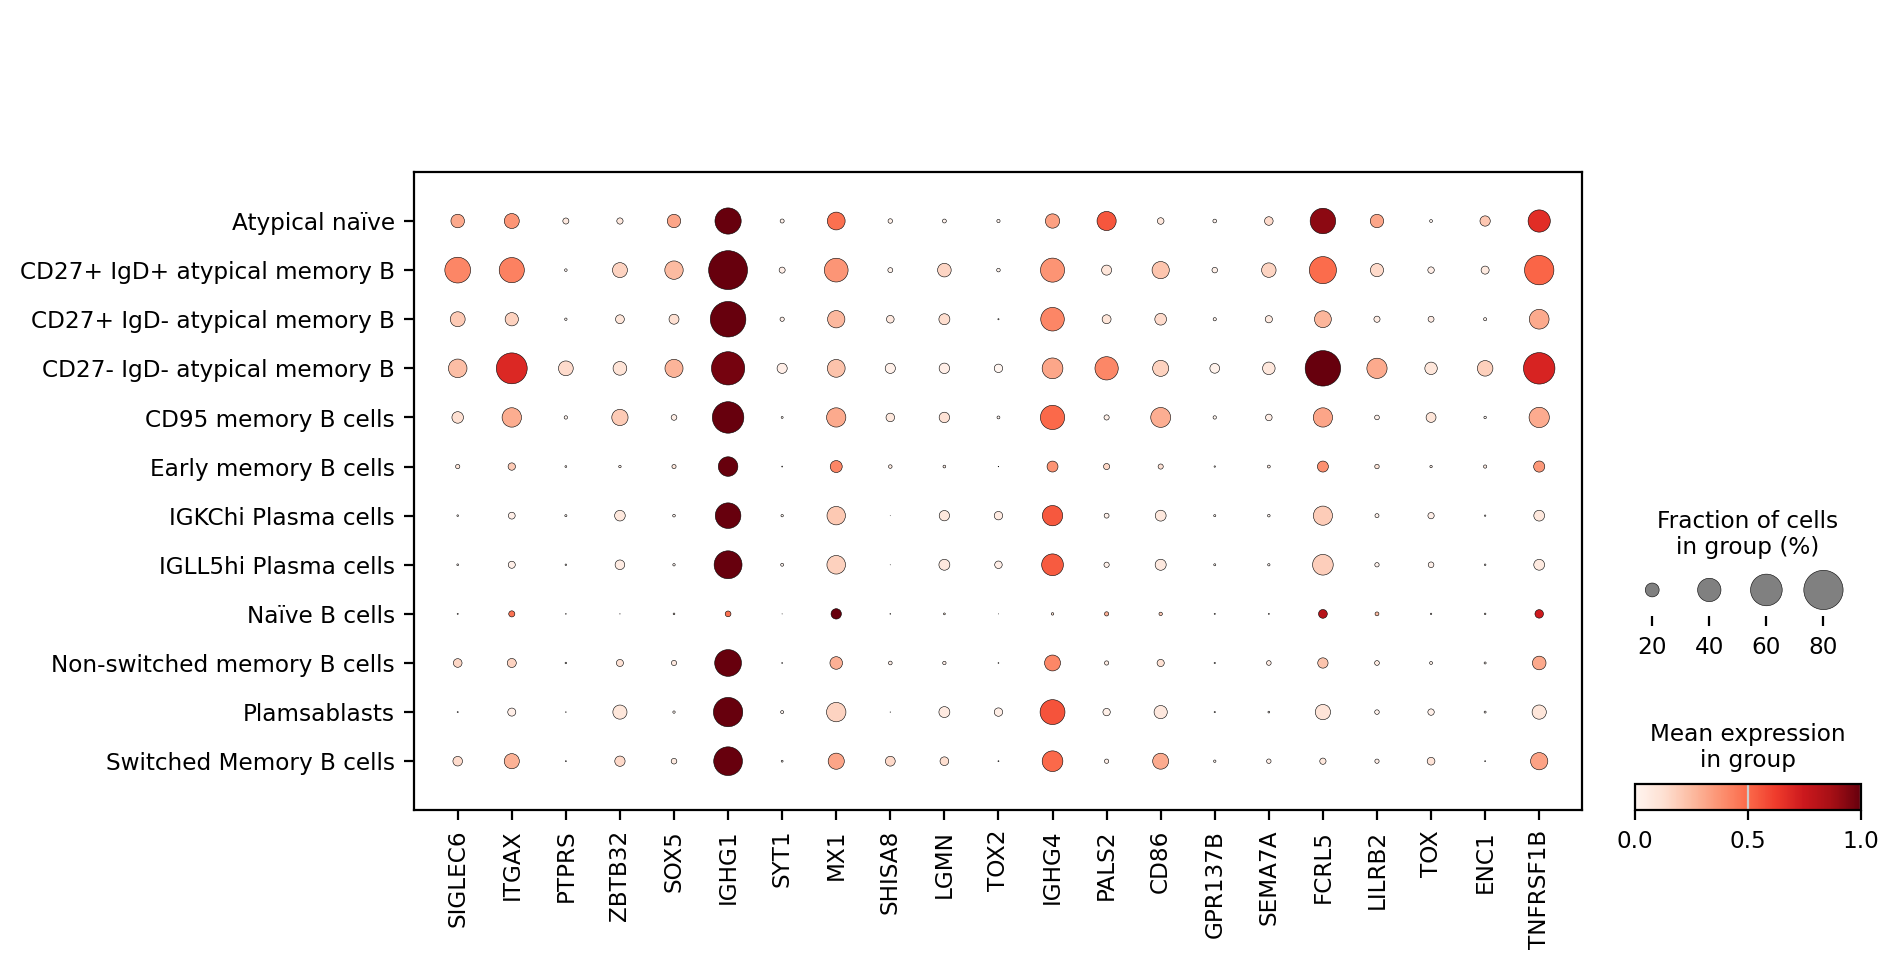

In [41]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B'],
              standard_scale='group',groupby=groupby)

In [51]:
a = sc.read_h5ad('/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R2/Plasma/Plasma_preprocess_scRNA.h5ad')

In [59]:
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 2000)

In [62]:
a.var.to_csv('a.csv')